# Reconstruction scorer

This notebook is used to run a reconstruction in several configurations, showing its score in the reconstruction of a given function

In [1]:
import sys
import pprint
import seaborn as sb
import numpy   as np
import pandas  as pd
import random  as rnd

from CoRe.reconstruction_tools.GaussianProcess import GPCalculator
from CoRe.utils.diagnostics import Scorer

from copy    import deepcopy
from time    import time
from tqdm    import tqdm
from itertools import product

from getdist import plots,MCSamples

#Plotting
import matplotlib
import matplotlib.pyplot as plt

from matplotlib import rc


rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c'
yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}
bottomlegend = {'bbox_to_anchor': (0.35,-0.2), 
                'loc': "center left",
                'frameon': False,
                'ncols': 3}

# Some functions

In [2]:
def get_theory(params):

    from numpy.polynomial import Polynomial
    
    p = Polynomial(params)
    # Compute derivatives and integral using NumPy's built-in methods
    p_deriv1 = p.deriv(m=1)   # First derivative
    p_deriv2 = p.deriv(m=2)   # Second derivative
    p_integ  = p.integ(m=1)   # Antiderivative (integration constant C=0)
    results = {'f': lambda x: p(x),
               'd1': lambda x: p_deriv1(x),
               'd2': lambda x: p_deriv2(x),
               'int': lambda x: p_integ(x)}

    return results

def create_data(theory_model,Ndata,xmin,xmax,err_fac):

    dataset = pd.DataFrame({'x': np.random.uniform(xmin,xmax,Ndata)})
    
    thvals = theory_model['f'](dataset['x'])
    errors = abs(thvals)*err_fac/100
    dataset['f'] = thvals#np.random.normal(thvals,errors)
    dataset['f_err'] = errors
    
    covmat = pd.DataFrame(np.diag(errors*2),columns=['f_{}'+format(ind) for ind in range(len(dataset['x']))])
    covmat.index = covmat.columns

    return dataset,covmat

def get_GP(dataset,covmat,kernel,x_recon,method):

    gp = GPCalculator(dataset,covmat,kernel_type=kernel,chatty=False)

    means, joint_cov, lml, info = gp.reconstruct(x_recon,method=method)

    return means,joint_cov,lml

# Diagnostic tools

Once a reconstruction is complete, it is critical to quantify how well the GP model represents the underlying physics. The Scorer class implements frequentist statistical tests to measure the "tension" between the reconstruction and other references.

## Interpreting the Results
The `Scorer` returns metrics to help interpret the statistical "tension":

* **Reduced $\chi^2$ ($\chi^2_{\nu}$):** Ideally near **1.0**. A value $\gg 1$ suggests the model is a poor fit or the tension is high; a value $\ll 1$ suggests the uncertainties are over-estimated.
* **p-value:** The probability of obtaining a result at least as extreme as the one observed.

### Tension Scale
The `Scorer` provides color-coded reports based on the p-value:
* **$p > 0.05$ (Green):** Good consistency. No significant evidence of tension.
* **$0.01 < p < 0.05$ (Yellow):** Marginal consistency. Potential tension that warrants investigation.
* **$p < 0.01$ (Red):** Poor consistency. Significant tension exists.

In [3]:
Nrecon  = 10
xmin    = 0.1
xmax    = 1.9
x_recon = np.linspace(xmin,xmax,Nrecon)

Ndata   = 20
mindata = 0.
maxdata = 2.
error   = 5

fiducial = {'a0': 3,
            'a1': -1,
            'a2': 5,
            'a3': -0.1}

method = 'MAP'
kernel = 'RBF'

derivatives = ['f','d1']
if kernel != 'MATERN3/2':
    derivatives = derivatives+['d2','int']

x_label = r'$x$'
y_label = r'$f(x)$'

In [4]:
theory = get_theory(list(fiducial.values()))

dataset,covmat = create_data(theory,Ndata,mindata,maxdata,error)

means,joint_cov,lml = get_GP(dataset,covmat,kernel,x_recon,method)

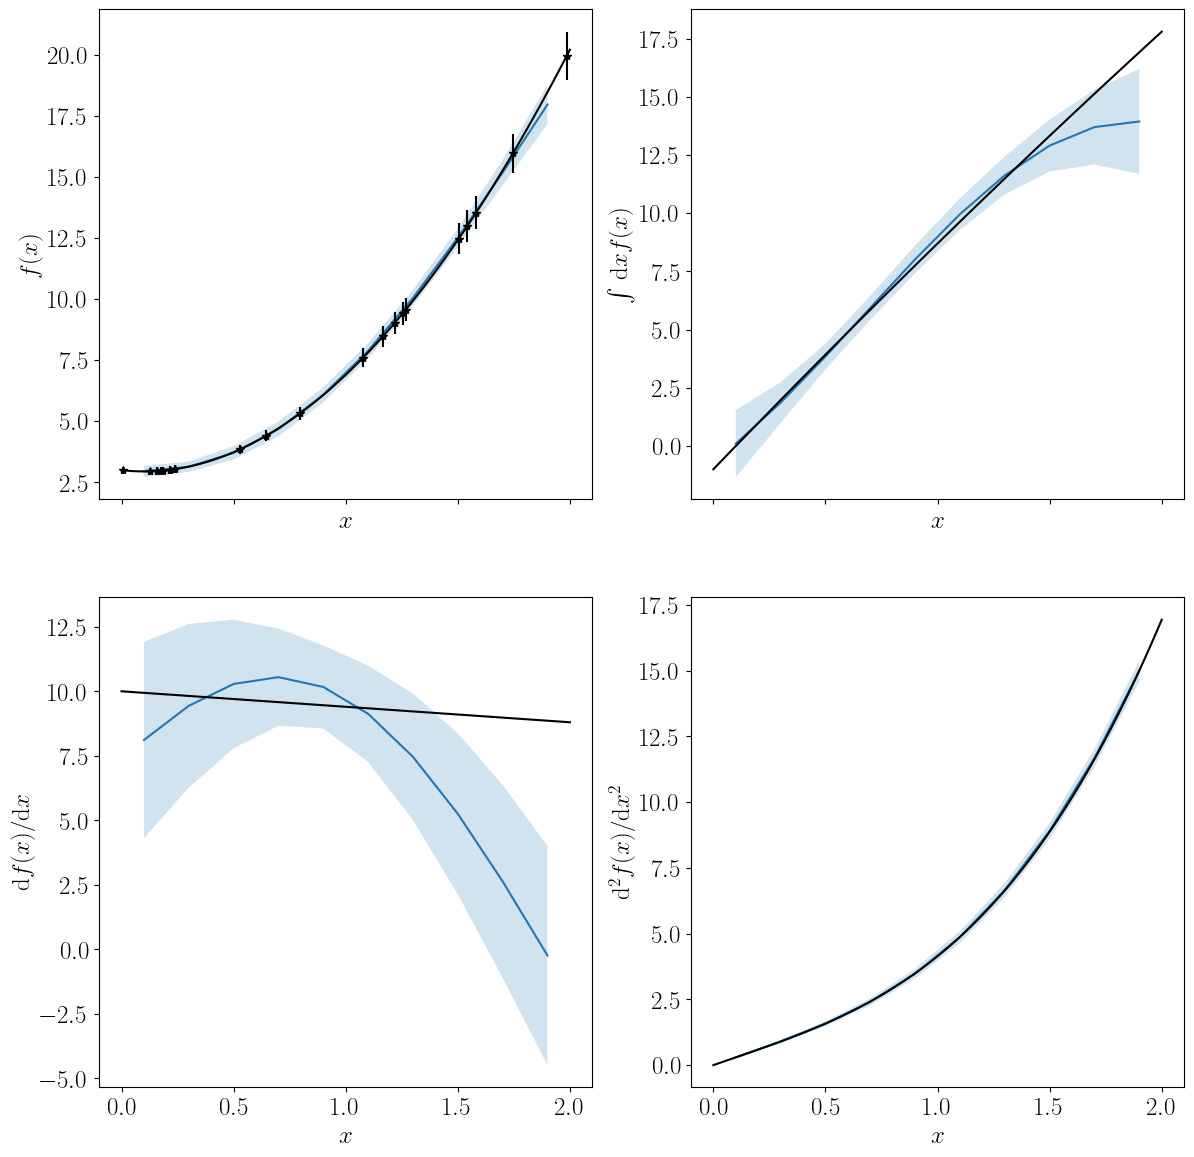

In [5]:
xplot = np.linspace(mindata,maxdata,100)
fig,axes = plt.subplots(nrows=2,ncols=2,sharey=False,sharex=True,figsize=(14,14))

for ind,deriv in enumerate(derivatives):
    if ind == 0:
        i = 0
        j = 0
        label = y_label
    elif ind == 1:
        i = 0
        j = 1
        label = r'$\int$ d'+x_label+''+y_label
    elif ind == 2:
        i = 1
        j = 0
        label = r'd'+y_label+'/d'+x_label
    elif ind == 3:
        i = 1
        j = 1
        label = r'd$^2$'+y_label+'/d'+x_label+r'$^2$'

    axes[i,j].fill_between(x_recon,means[deriv]+means[deriv+'_err'],means[deriv]-means[deriv+'_err'],alpha=0.2)
    axes[i,j].plot(means['x'],means[deriv])
    axes[i,j].plot(xplot,theory[deriv](xplot),color='black')
    if deriv == 'f':
        axes[i,j].errorbar(dataset['x'],dataset[deriv],yerr=dataset[deriv+'_err'],color='black',ls='',marker='*')
    axes[i,j].set_xlabel(x_label)
    axes[i,j].set_ylabel(label)

## Initialize Scorer

**Explain**

In [6]:
from CoRe.utils.diagnostics import Scorer

scorer = Scorer(means,joint_cov,chatty=True)

In [7]:
GPdiagnostic = pd.DataFrame(columns=['chi2','chi2_reduced','p-value','dof']+[func+'%' for func in derivatives])

## 1. Scoring Against Theory (Accuracy)

When evaluating how well a reconstruction matches a theoretical curve $y_{th}(x)$, we must decide how to treat the relationship between different points in the reconstruction. The `Scorer` class provides two distinct statistical perspectives.

In [8]:
theory_df = pd.DataFrame({'x': x_recon}|{func: theory[func](x_recon) for func in derivatives})

### A. The Mahalanobis Distance (Joint Scoring)
The Mahalanobis distance measures the separation between the GP mean vector and the theory vector by accounting for the **full joint covariance matrix** ($\Sigma_{GP}$), including all off-diagonal correlations.

$$\chi^2_{joint} = (\vec{\mu}_{GP} - \vec{y}_{th})^T \mathbf{\Sigma}_{GP}^{-1} (\vec{\mu}_{GP} - \vec{y}_{th})$$

* **Global Shape Consistency:** It treats the entire curve as a single physical realization. Because GPs are smooth, a deviation at $x_1$ is physically linked to a deviation at $x_2$ via the kernel.
* **The "Rigidity" Factor:** This metric is highly sensitive to "shape" mismatches. If the theory curve has a slope or feature that the GP kernel cannot replicate, the Mahalanobis distance will increase significantly, even if the error bars are large.
* **When to use:** This is the most mathematically rigorous test for Gaussian Processes.

In [10]:
Mscore = scorer.score_against_theory(theory_df)
GPdiagnostic.loc['Mahalanobis'] = [val for key,val in Mscore.items() 
                                   if key not in ['breakdown','eigenvalues','chi2_per_mode']]+[Mscore['breakdown'][func]['percentage']
                                                                                               for func in derivatives]


 SCORE REPORT: THEORY CONSISTENCY
Status: POOR (Significant Tension)
Total Chi2: 509186.25
Red.  Chi2: 12729.656
P-value:    0.0000
DOF:        40

Residual Breakdown:
  - f   : 26977853140.73 (5298229.0%)
  - d1  : 835014085404.71 (163989913.7%)
  - d2  : 826103271194.22 (162239902.9%)
  - int : 340891867.70 (66948.4%)

Mode   | Eigenvalue   | Chi2 Contribution
-------------------------------------------------------
0      | 6.97e+01     | 1.22           
1      | 2.26e+01     | 0.96           
2      | 9.33e+00     | 5.47           
3      | 1.68e+00     | 0.01           
4      | 4.51e-01     | 0.00           
5      | 3.47e-01     | 0.89           
6      | 7.41e-03     | 10.52          
7      | 1.06e-04     | 0.83           
8      | 1.03e-06     | 15.53          
9      | 6.72e-09     | 0.77           
10     | 3.74e-11     | 15.16          
11     | 1.08e-11     | 2004.88        
12     | 1.07e-11     | 144363.68      
13     | 1.05e-11     | 2764.81        
14     | 1.03e-11 

### B. Pointwise $\chi^2$ Scoring

The pointwise score ignores the correlations (off-diagonal elements) and compares the mean to the theory at each point using only the local variance $\sigma^2_i$.

$$\chi^2_{pointwise} = \sum_{i=1}^{N} \frac{(\mu_i - y_{th, i})^2}{\sigma_i^2}$$

* **Local Accuracy:** This answers the question: "At this specific redshift, how many sigma away is my reconstruction from the theory?"
* **Visual Intuition:** This matches our visual interpretation of plots. If the theory line stays within the $1\sigma$ shaded region, the pointwise $\chi^2$ per degree of freedom will be small.
* **The Risk of Over-optimism:** Because it ignores correlations, pointwise scoring often results in artificially high p-values. It "forgets" that the GP isn't allowed to fluctuate independently at every point, which can make a mediocre fit look statistically acceptable.

In [11]:
Dscore = scorer.score_pointwise(theory_df)
GPdiagnostic.loc['Pointwise'] = [val for key,val in Dscore.items() 
                                 if key not in ['breakdown','eigenvalues','chi2_per_mode']]+[Dscore['breakdown'][func]['percentage']
                                                                                             for func in derivatives]


 SCORE REPORT: POINTWISE THEORY CONSISTENCY
Status: GOOD (Consistent)
Total Chi2: 14.20
Red.  Chi2: 0.355
P-value:    0.9999
DOF:        40

Residual Breakdown:
  - f   :     0.69 (  4.9%)
  - d1  :     3.19 ( 22.4%)
  - d2  :    10.27 ( 72.3%)
  - int :     0.05 (  0.4%)



## 2. Scoring Against Data (Consistency)
This method compares the reconstruction against external data points that were not used in the training, or checks the self-consistency of the fit against a secondary probe.

### The Logic
Unlike the theory score, we must account for the uncertainties in **both** the reconstruction and the data. The total covariance is the sum of the two:

$$\chi^2_{data} = (\vec{y}_{data} - \vec{\mu}_{GP})^T \left[ \mathbf{\Sigma}_{GP} + \mathbf{\Sigma}_{data} \right]^{-1} (\vec{y}_{data} - \vec{\mu}_{GP})$$

The `Scorer` automatically handles the alignment of coordinates, extracting the GP's predicted values and covariance at the specific $x$-locations where the data points exist.

In [12]:
datasets = [{'type': 'f',
             'df': dataset,
             'cov': covmat}]

In [13]:
data_score = scorer.score_against_data(datasets)
GPdiagnostic.loc['Data'] = [val for key,val in data_score.items() 
                            if key not in ['breakdown','eigenvalues','chi2_per_mode']]+[np.nan for func in derivatives]


 SCORE REPORT: EXTERNAL DATA VALIDATION
Status: GOOD (Consistent)
Total Chi2: 5.95
Red.  Chi2: 0.298
P-value:    0.9990
DOF:        20

Mode   | Eigenvalue   | Chi2 Contribution
-------------------------------------------------------
0      | 2.98e+00     | 1.46           
1      | 1.95e+00     | 0.18           
2      | 1.58e+00     | 0.01           
3      | 1.33e+00     | 0.31           
4      | 1.27e+00     | 0.33           
5      | 1.18e+00     | 0.28           
6      | 9.51e-01     | 0.00           
7      | 9.24e-01     | 0.09           
8      | 8.94e-01     | 2.07           
9      | 7.96e-01     | 0.05           
10     | 6.78e-01     | 0.26           
11     | 5.93e-01     | 0.06           
12     | 4.85e-01     | 0.64           
13     | 4.08e-01     | 0.03           
14     | 3.25e-01     | 0.17           
15     | 3.03e-01     | 0.00           
16     | 2.99e-01     | 0.00           
17     | 2.98e-01     | 0.00           
18     | 2.97e-01     | 0.00           
19   

In [ ]:
GPdiagnostic

# Reconstruction grid

Here we use the scorer module to visualize the dependence of a Gaussian Process on different settings, running on a grid of several choice combinations.

**TO BE FINISHED!!!**

## Settings

In [ ]:
data_range  = [0.,2.]
recon_range = [0.1,1.8]


free_settings = {'Nrecon': [5,7,10,12,15],
                 'order': [3,4,5],
                 'Ndata': [25,50,75,100],
                 'error': [1,5,10.],
                 'kernel': ['RBF'],
                 'method': ['MAP']}


prior_sampling = 1

## Run grid

In [ ]:
import math
dfs = []

keys = free_settings.keys()

locind = 0
total  = math.prod(len(v) for v in free_settings.values())*prior_sampling
for values in product(*free_settings.values()):

    print('')
    loc_dict = dict(zip(keys, values))

    x_recon = np.linspace(recon_range[0],recon_range[1],loc_dict['Nrecon'])

    for Nint in range(prior_sampling):

        tini = time()

        df = pd.DataFrame(loc_dict,index=[0])
        df['Iteration'] = Nint+1
        
        params = {'a{}'.format(ind): np.random.uniform(-5.,5) for ind in range(loc_dict['order']+1)}
        #params = deepcopy(fiducial)
        

        theory = get_theory(list(params.values()))

        dataset,covmat = create_data(theory,loc_dict['Ndata'],data_range[0],data_range[1],loc_dict['error'])

        means,joint_cov,lml = get_GP(dataset,covmat,loc_dict['kernel'],x_recon,loc_dict['method'])

        scorer = Scorer(means,joint_cov,chatty=False)

        theory_df = pd.DataFrame({'x': x_recon}|{func: theory[func](x_recon) for func in ['f','d1','d2','int']})
        res         = scorer.score_against_theory(theory_df)

        df['M-score']   = res['red_chi2']
        for func in ['f','d1','d2','int']:
            df['M-score_'+func] = res['breakdown'][func]['percentage']

        res = scorer.score_pointwise(theory_df)

        df['D-score'] = res['red_chi2']
        for func in ['f','d1','d2','int']:
            df['D-score_'+func] = res['breakdown'][func]['percentage']

        datasets = [{'type': 'f',
                     'df': dataset,
                     'cov': covmat}]

        res = scorer.score_against_data(datasets)

        df['Data score'] = res['red_chi2']

        dfs.append(df)
        
        print('Test {} of {} done in {:.2f} s'.format(locind+1,total,time()-tini))

        locind += 1

results = pd.concat(dfs,ignore_index=True)

In [ ]:
results

In [ ]:
import plotly.express as px # Plotly is better for interactive Parallel Coordinates

# Assuming 'df' is your results dataframe
# 1. Normalize the Score to a 0-1 range for better coloring
#df['Score_Norm'] = (df['Score'] - df['Score'].min()) / (df['Score'].max() - df['Score'].min())

# 2. Create an interactive plot
fig = px.parallel_coordinates(results, 
    dimensions=['Nrecon', 'Ndata', 'error'],#, 'order', 'Iteration'],
    color="Data score",
    color_continuous_scale=px.colors.sequential.Viridis_r, # _r so low is yellow/distinct
    title="Reconstruction Performance Grid")
plt.show()

In [ ]:
for score in ['D-score','Data score']:
    plt.figure(figsize=(12, 6))
    sb.boxplot(data=results, x='Ndata', y=score, hue='Nrecon', palette='Set2')
    plt.title("{} score Distribution and Stability per Ndata/Order".format(score));

In [ ]:
df_mean = results.groupby(['Nrecon', 'Ndata', 'order'])['Data score'].mean().reset_index()

# Create a grid where each 'order' gets its own heatmap
g = sb.FacetGrid(df_mean, col="order", height=5)

def draw_heatmap(*args, **kwargs):
    data = kwargs.pop('data')
    d = data.pivot(index='Nrecon', columns='Ndata', values='Data score')
    sb.heatmap(d, annot=True, cmap='magma_r', **kwargs)

g.map_dataframe(draw_heatmap)
g.set_axis_labels("N Data Points", "N Reconstruction");